In [ ]:

# =========================================================================================
import hashlib
import os
import random

import nltk
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset

nltk.download("punkt", quiet=True)
try:
    nltk.download("punkt_tab", quiet=True)
except Exception:
    pass

# ---- the agreed settings ----------------------------------------------------------------
SHARED_SEED = 42                 # fixes the random sample
SHARED_N_PAIRS = 100_000         # how many sentence pairs both questions train on
MIN_TOKENS, MAX_TOKENS = 5, 80   # keep real sentences, drop UI labels and huge outliers
SHARED_MIN_COUNT = 2             # a word must appear this many times to enter the vocabulary

IITB_REPO = "cfilt/iitb-english-hindi"   # loaded with datasets.load_dataset
SHARED_CACHE = "shared_corpus.csv"       # written once, then reused


def set_shared_seed(seed=SHARED_SEED):
    """
    Fix EVERY random number generator to the agreed seed.

    Call this at the start of each training run, not only once at the top of the notebook:
    if we run cells in a different order, the generators are in a different state, and the
    models would differ even with the same data. Calling it before each run makes the result
    independent of what was run before.

    Honest limitation: identical seeds give identical results on the SAME machine. Across
    different GPUs the arithmetic order differs slightly, so numbers can still drift a
    little. Same seed removes every source of difference we control.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    return seed


def shared_generator(seed=SHARED_SEED):
    """A seeded torch generator, so DataLoader shuffling is reproducible too."""
    g = torch.Generator()
    g.manual_seed(seed)
    return g


def shared_tokenize(text):
    """
    The tokenizer BOTH questions use: NLTK word_tokenize on the lowercased text.

    Input:  a single sentence (str)
    Output: list[str] of tokens
    """
    return nltk.word_tokenize(str(text).lower())


def load_shared_corpus(n_pairs=SHARED_N_PAIRS, seed=SHARED_SEED, cache=SHARED_CACHE):
    """
    Return the agreed corpus as a DataFrame with columns ["en", "hi"].

    The rows are sampled from ACROSS the whole file, never from the front: the file is
    ordered by source, and its first rows are software menu labels ("Num", "API Browser"),
    which are 82% duplicates and average 5 words. A model trained on those learns nothing.

    Determinism: the file is read in a fixed order, filtered by fixed rules, then permuted
    with a fixed seed. Same seed and same n_pairs -> the same rows, on any machine.
    Once written, `cache` is reused, so the corpus can never drift between runs.
    """
    if os.path.exists(cache):
        df = pd.read_csv(cache, keep_default_na=False)
        print(f"loaded the shared corpus from {cache}")
    else:
        # loaded through Hugging Face `datasets`, the same way Question 5 loads it
        ds = load_dataset(IITB_REPO, split="train")
        df = pd.DataFrame({"en": ds["translation"]["en"],
                           "hi": ds["translation"]["hi"]})

        # every one of the sampled rows must be UNIQUE: dropping duplicate pairs is not
        # enough, because the same English sentence appears with several different Hindi
        # translations. Deduplicate each side on its own, so no sentence -- English or
        # Hindi -- is ever seen twice. Repeated text is what lets a count-based n-gram
        # memorise the corpus, which makes the comparison with the NNLM meaningless.
        df = df.dropna()
        df = df.drop_duplicates(subset=["en"]).drop_duplicates(subset=["hi"])
        en_len = df["en"].str.split().str.len()
        hi_len = df["hi"].str.split().str.len()
        df = df[(en_len >= MIN_TOKENS) & (en_len <= MAX_TOKENS) & (hi_len >= MIN_TOKENS)]
        df = df.reset_index(drop=True)

        # keep the SHUFFLED order, do not sort back: the file is grouped by source, so an
        # in-order sample would put software text in train and news in test.
        order = np.random.RandomState(seed).permutation(len(df))[:n_pairs]
        df = df.iloc[order].reset_index(drop=True)
        df.to_csv(cache, index=False)
        print(f"sampled {len(df):,} pairs and wrote {cache}")

    fp = hashlib.md5(("\n".join(df["en"]) + "\n".join(df["hi"])).encode("utf-8")).hexdigest()
    lens = df["en"].str.split().str.len()
    print(f"sentence pairs: {len(df):,} | English tokens: {int(lens.sum()):,} "
          f"| mean {lens.mean():.1f} per sentence")
    print(f"FINGERPRINT: {fp[:16]}   <-- this must be identical for both of us")
    return df


set_shared_seed()
corpus_df = load_shared_corpus()

# the names Question 5 already uses, so nothing else in that question has to change
en_train_texts = corpus_df["en"].tolist()
hi_train_texts = corpus_df["hi"].tolist()

print("\nsanity check -- these must be sentences, not menu labels:")
for s in en_train_texts[:3]:
    print("   ", s[:90])

README.md: 0.00B [00:00, ?B/s]

dataset_infos.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/190M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/85.7k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/500k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1659083 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/520 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2507 [00:00<?, ? examples/s]

sampled 100,000 pairs and wrote shared_corpus.csv
sentence pairs: 100,000 | English tokens: 1,785,684 | mean 17.9 per sentence
FINGERPRINT: 3d641e5660c7b804   <-- this must be identical for both of us

sanity check -- these must be sentences, not menu labels:
    In the history of terrorism, the terrorist attack on the United States on September 11, 20
    It was both a struggle against foreign rule, as well as an ethical campaign against unreas
    Technical Processing Section plays a key role in the functioning of the library.


In [2]:
import heapq
import os
import pickle
import random
import time
from collections import Counter
 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
 
try:
    import umap.umap_ as umap
except ImportError:
    import umap
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# ============================================================================
# 1. PREPROCESSING (verbatim, shared with the NNLM question)
# ============================================================================
def preprocess_and_build_vocab(corpus_texts, min_count=SHARED_MIN_COUNT):
    """
    Tokenizes, lowercases, prunes by min_count, and assigns indices
    sorted by frequency (0 = most frequent).
    """
    print("Tokenizing corpus...")
    if isinstance(corpus_texts, list):
        tokens = [tok for s in corpus_texts if s for tok in shared_tokenize(s)]
    else:
        tokens = shared_tokenize(corpus_texts)
 
    freq_dict = Counter(tokens)
    filtered_tokens = [w for w, c in freq_dict.items() if c >= min_count]
    filtered_tokens.sort(key=lambda w: freq_dict[w], reverse=True)
 
    stoi = {w: i for i, w in enumerate(filtered_tokens)}
    itos = {i: w for i, w in enumerate(filtered_tokens)}
    frequencies = {stoi[w]: freq_dict[w] for w in filtered_tokens}
 
    print("Encoding corpus...")
    encoded_corpus = [stoi[w] for w in tokens if w in stoi]
    print(f" -> vocab size: {len(stoi):,} | corpus tokens (post-prune): {len(encoded_corpus):,}")
    return encoded_corpus, stoi, itos, frequencies

In [4]:
# ============================================================================
# 2. FAST CONTEXT-WINDOW CONSTRUCTION (vectorized — no O(N*window) Python loop)
# ============================================================================
def build_context_matrix(encoded_corpus, window_size, pad_id):
    """
    Builds a (N, 2*window_size) int64 array of context word ids for every position,
    using pure NumPy striding instead of a Python double loop. This is the main
    optimization needed to make preprocessing tractable on ~1M-token corpora:
    the naive nested-loop version in earlier drafts is O(N * window) in *Python*,
    which is minutes-to-hours slower than the vectorized version below.
    """
    arr = np.asarray(encoded_corpus, dtype=np.int64)
    n = len(arr)
    w = window_size
    padded = np.full(n + 2 * w, pad_id, dtype=np.int64)
    padded[w : w + n] = arr
 
    # sliding_window_view gives, for each center position i, the full window
    # [i-w, ..., i+w] (2w+1 wide); we then drop the center column.
    windows = np.lib.stride_tricks.sliding_window_view(padded, 2 * w + 1)  # (n, 2w+1)
    contexts = np.delete(windows, w, axis=1)  # drop center -> (n, 2w)
    return contexts

In [5]:
# ============================================================================
# 3. HUFFMAN TREE (for Hierarchical Softmax)
# ============================================================================
class HuffmanNode:
    __slots__ = ("freq", "word_idx", "left", "right", "internal_idx")
 
    def __init__(self, freq, word_idx=None):
        self.freq = freq
        self.word_idx = word_idx
        self.left = None
        self.right = None
        self.internal_idx = None
 
    def __lt__(self, other):
        return self.freq < other.freq
 
 
def build_huffman_tree(frequencies):
    """Left = +1, Right = -1. Prints leaf/internal/total node counts."""
    num_leaves = len(frequencies)
    heap = [HuffmanNode(freq, word_idx=w) for w, freq in frequencies.items()]
    heapq.heapify(heap)
 
    internal_idx = 0
    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        parent = HuffmanNode(left.freq + right.freq)
        parent.left, parent.right = left, right
        parent.internal_idx = internal_idx
        internal_idx += 1
        heapq.heappush(heap, parent)
 
    print("Huffman Tree built:")
    print(f" -> Leaf nodes (vocabulary words): {num_leaves}")
    print(f" -> Internal nodes: {internal_idx}")
    print(f" -> Total nodes: {num_leaves + internal_idx}")
 
    root = heap[0]
    paths, codes = {}, {}
 
    def traverse(node, path, code):
        if node.word_idx is not None:
            paths[node.word_idx] = path
            codes[node.word_idx] = code
            return
        traverse(node.left, path + [node.internal_idx], code + [1])
        traverse(node.right, path + [node.internal_idx], code + [-1])
 
    traverse(root, [], [])
    return paths, codes, internal_idx
 
 
def pad_paths_codes(paths, codes, vocab_size, num_internal_nodes):
    max_len = max(len(p) for p in paths.values())
    padded_paths = np.full((vocab_size, max_len), num_internal_nodes, dtype=np.int64)
    padded_codes = np.zeros((vocab_size, max_len), dtype=np.float32)
    masks = np.zeros((vocab_size, max_len), dtype=np.float32)
    for w_idx in range(vocab_size):
        p, c = paths[w_idx], codes[w_idx]
        length = len(p)
        padded_paths[w_idx, :length] = p
        padded_codes[w_idx, :length] = c
        masks[w_idx, :length] = 1.0
    return padded_paths, padded_codes, masks
 

In [6]:
# ============================================================================
# 4. NEGATIVE SAMPLING TABLE (unigram^0.75, built once)
# ============================================================================
def build_negative_sampling_table(frequencies, vocab_size, table_size=int(1e7)):
    """
    Standard Word2Vec unigram^0.75 sampling table, built once and reused every batch.
    Returns an int64 NumPy array of word ids of length `table_size`; sampling is then
    just `table[np.random.randint(0, table_size, size=...)]`, O(1) per draw.
    """
    freqs = np.array([frequencies.get(i, 0) for i in range(vocab_size)], dtype=np.float64)
    probs = freqs ** 0.75
    probs /= probs.sum()
    counts = np.round(probs * table_size).astype(np.int64)
    table = np.repeat(np.arange(vocab_size), counts)
    if len(table) == 0:  # degenerate tiny-vocab edge case
        table = np.arange(vocab_size)
    return table.astype(np.int64)
 

In [7]:
len(en_train_texts)

100000

In [8]:
# ============================================================================
# 5. DATASET
# ============================================================================
class CBOWDataset(Dataset):
    """
    Pre-computes ALL context windows into one NumPy array up front (vectorized, see
    build_context_matrix), then does O(1) index lookups in __getitem__. Targets are
    served as plain ids; both the HS paths/codes/masks and NS negative sampling are
    looked up / drawn at collate time in the training loop (see `train_word2vec`),
    not per-item, so DataLoader workers stay cheap.
    """
 
    def __init__(self, encoded_corpus, window_size, vocab_size):
        self.vocab_size = vocab_size
        contexts = build_context_matrix(encoded_corpus, window_size, pad_id=vocab_size)
        self.contexts = torch.from_numpy(contexts)
        self.targets = torch.tensor(encoded_corpus, dtype=torch.long)
 
    def __len__(self):
        return len(self.targets)
 
    def __getitem__(self, i):
        return self.contexts[i], self.targets[i]
 

In [9]:
# ============================================================================
# 6. MODELS  (no nonlinearity on the pooled context vector, by design)
# ============================================================================
class CBOWBase(nn.Module):
    """Shared context-pooling logic for all three variants."""
 
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.vocab_size = vocab_size
        self.in_embeddings = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=vocab_size)
        nn.init.uniform_(self.in_embeddings.weight, -0.5 / embed_dim, 0.5 / embed_dim)
        with torch.no_grad():
            self.in_embeddings.weight[vocab_size].zero_()
 
    def pool_context(self, contexts):
        embeds = self.in_embeddings(contexts)
        valid_counts = (contexts != self.vocab_size).sum(dim=1, keepdim=True).clamp(min=1)
        h = embeds.sum(dim=1) / valid_counts
        # NOTE: intentionally linear. Do not apply ReLU/tanh/etc. here — Word2Vec's
        # linear analogy structure depends on the composition staying additive.
        return h
 
 


In [10]:
class CBOWFullSoftmax(CBOWBase):
    """Part A — diagnostic only, not meant to be trained to convergence."""
 
    def __init__(self, vocab_size, embed_dim):
        super().__init__(vocab_size, embed_dim)
        self.out_embeddings = nn.Linear(embed_dim, vocab_size, bias=False)
 
    def forward(self, contexts, targets):
        h = self.pool_context(contexts)
        logits = self.out_embeddings(h)  # (B, V) <-- the expensive O(V*d) matmul
        return F.cross_entropy(logits, targets)
 
 


In [11]:
class CBOWNegativeSampling(CBOWBase):
    def __init__(self, vocab_size, embed_dim):
        super().__init__(vocab_size, embed_dim)
        self.out_embeddings = nn.Embedding(vocab_size, embed_dim)
        nn.init.zeros_(self.out_embeddings.weight)
 
    def forward(self, contexts, targets, negatives):
        # negatives: (B, k) ids sampled from the unigram^0.75 table
        h = self.pool_context(contexts)                      # (B, d)
        u_pos = self.out_embeddings(targets)                  # (B, d)
        u_neg = self.out_embeddings(negatives)                # (B, k, d)
 
        pos_score = (h * u_pos).sum(dim=1)                    # (B,)
        neg_score = torch.bmm(u_neg, h.unsqueeze(2)).squeeze(2)  # (B, k)
 
        pos_loss = F.logsigmoid(pos_score)
        neg_loss = F.logsigmoid(-neg_score).sum(dim=1)
        return -(pos_loss + neg_loss).mean()
 
 


In [12]:
class CBOWHierarchicalSoftmax(CBOWBase):
    def __init__(self, vocab_size, num_internal_nodes, embed_dim):
        super().__init__(vocab_size, embed_dim)
        self.W_internal = nn.Embedding(num_internal_nodes + 1, embed_dim, padding_idx=num_internal_nodes)
        nn.init.zeros_(self.W_internal.weight)
 
    def forward(self, contexts, paths, codes, masks):
        h = self.pool_context(contexts)                       # (B, d)
        v_nodes = self.W_internal(paths)                       # (B, L, d)
        dot = torch.bmm(v_nodes, h.unsqueeze(2)).squeeze(2)     # (B, L)
        log_probs = F.logsigmoid(codes * dot)
        return -(log_probs * masks).sum(dim=1).mean()
 

In [13]:
def visualize_embeddings(embeddings, stoi, itos, label=""):
    random.seed(SHARED_SEED)  # local, deterministic sample of words for this plot
    vocab_words = [w for w in stoi.keys() if w not in ("<unk>", "<pad>")]
    sampled_words = random.sample(vocab_words, min(50, len(vocab_words)))
 
    norm_E = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-9)
    selected = set()
    for word in sampled_words:
        idx = stoi[word]
        selected.add(idx)
        sims = norm_E @ norm_E[idx]
        sims[idx] = -np.inf
        selected.update(np.argsort(sims)[-10:].tolist())
 
    selected = list(selected)
    matrix = embeddings[selected]
    labels = [itos[i] for i in selected]
 
    tsne = TSNE(n_components=2, random_state=SHARED_SEED,
                perplexity=min(30, len(matrix) - 1))
    tsne_xy = tsne.fit_transform(matrix)
    fig_tsne = px.scatter(pd.DataFrame({"x": tsne_xy[:, 0], "y": tsne_xy[:, 1], "word": labels}),
                           x="x", y="y", text="word", title=f"t-SNE | {label} | CBOW")
    fig_tsne.update_traces(textposition="top center")
    fig_tsne.show()
 
    reducer = umap.UMAP(n_components=2, random_state=SHARED_SEED)
    umap_xy = reducer.fit_transform(matrix)
    fig_umap = px.scatter(pd.DataFrame({"x": umap_xy[:, 0], "y": umap_xy[:, 1], "word": labels}),
                           x="x", y="y", text="word", title=f"UMAP | {label} | CBOW")
    fig_umap.update_traces(textposition="top center")
    fig_umap.show()

In [14]:
def train_word2vec_softmax(encoded_corpus, stoi, epochs=5, embed_dim=100, window=5,
                           batch_size=4096, lr=0.01, label=""):
    """
    Part A: Full Softmax. 
    Note: Batch size defaults to 1024 to prevent OOM on the massive (V, D) output projection.
    This should typically be run on a small subset of the corpus as per the assignment.
    """
    set_shared_seed()  # Reset RNG state
    vocab_size = len(stoi)

    dataset = CBOWDataset(encoded_corpus, window, vocab_size)
    
    g = shared_generator()
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=True, generator=g,
        num_workers=min(4, os.cpu_count() or 1),
        pin_memory=torch.cuda.is_available(), drop_last=False,
    )

    model = CBOWFullSoftmax(vocab_size, embed_dim).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    epoch_losses = []
    for epoch in range(epochs):
        model.train()
        total_loss, n_batches = 0.0, 0
        pbar = tqdm(dataloader, desc=f"[{label} | Full Softmax] Epoch {epoch + 1}/{epochs}")
        
        for contexts, targets in pbar:
            contexts = contexts.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=torch.cuda.is_available()):
                loss = model(contexts, targets)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            n_batches += 1
            pbar.set_postfix({"loss": f"{total_loss / n_batches:.4f}"})

        epoch_losses.append(total_loss / max(n_batches, 1))

    plt.figure()
    plt.plot(range(1, epochs + 1), epoch_losses, marker="o")
    plt.title(f"CBOW + Full Softmax ({label})")
    plt.xlabel("Epoch")
    plt.ylabel("Average loss")
    plt.grid(True)
    plt.savefig(f"{label.lower()}_softmax_loss_curve.png", dpi=150, bbox_inches="tight")
    plt.show()

    return model.in_embeddings.weight.detach().cpu().numpy()[:vocab_size]

In [15]:
# ============================================================================
# 7. TRAINING (Negative Sampling — the variant used for the full runs)
# ============================================================================
def train_word2vec_ns(encoded_corpus, stoi, freq, epochs=5, embed_dim=100, window=5,
                       k_negatives=5, batch_size=4096, lr=0.01, label=""):
    set_shared_seed()  # reset RNG state right before each language's run
    vocab_size = len(stoi)
 
    dataset = CBOWDataset(encoded_corpus, window, vocab_size)
    neg_table = build_negative_sampling_table(freq, vocab_size)
    neg_table_t = torch.from_numpy(neg_table)
 
    g = shared_generator()
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=True, generator=g,
        num_workers=min(4, os.cpu_count() or 1),
        pin_memory=torch.cuda.is_available(), drop_last=False,
    )
 
    model = CBOWNegativeSampling(vocab_size, embed_dim).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
 
    epoch_losses = []
    for epoch in range(epochs):
        model.train()
        total_loss, n_batches = 0.0, 0
        pbar = tqdm(dataloader, desc=f"[{label}] Epoch {epoch + 1}/{epochs}")
        for contexts, targets in pbar:
            contexts = contexts.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)
 
            # Draw negatives on the fly from the precomputed table -- O(1) per draw,
            # fully vectorized, no per-example Python loop.
            neg_idx = torch.randint(0, len(neg_table_t), (targets.size(0), k_negatives))
            negatives = neg_table_t[neg_idx].to(DEVICE, non_blocking=True)
 
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=torch.cuda.is_available()):
                loss = model(contexts, targets, negatives)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
 
            total_loss += loss.item()
            n_batches += 1
            pbar.set_postfix({"loss": f"{total_loss / n_batches:.4f}"})
 
        epoch_losses.append(total_loss / max(n_batches, 1))
 
    plt.figure()
    plt.plot(range(1, epochs + 1), epoch_losses, marker="o")
    plt.title(f"CBOW + Negative Sampling ({label})")
    plt.xlabel("Epoch")
    plt.ylabel("Average loss")
    plt.grid(True)
    plt.savefig(f"{label.lower()}_loss_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
 
    return model.in_embeddings.weight.detach().cpu().numpy()[:vocab_size]
 
 

In [16]:
def train_word2vec_hs(encoded_corpus, stoi, freq, epochs=5, embed_dim=100, window=5,
                      batch_size=4096, lr=0.01, label=""):
    """
    Part C: Hierarchical Softmax.
    Preloads padded paths/codes to the GPU for O(1) lookup during the forward pass.
    """
    set_shared_seed()  # Reset RNG state
    vocab_size = len(stoi)

    # Build and pad Huffman tree
    paths, codes, num_internal = build_huffman_tree(freq)
    padded_paths, padded_codes, masks = pad_paths_codes(paths, codes, vocab_size, num_internal)
    
    # Send precomputed lookups directly to device
    padded_paths_t = torch.from_numpy(padded_paths).to(DEVICE)
    padded_codes_t = torch.from_numpy(padded_codes).to(DEVICE)
    masks_t = torch.from_numpy(masks).to(DEVICE)

    dataset = CBOWDataset(encoded_corpus, window, vocab_size)
    g = shared_generator()
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=True, generator=g,
        num_workers=min(4, os.cpu_count() or 1),
        pin_memory=torch.cuda.is_available(), drop_last=False,
    )

    model = CBOWHierarchicalSoftmax(vocab_size, num_internal, embed_dim).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    epoch_losses = []
    for epoch in range(epochs):
        model.train()
        total_loss, n_batches = 0.0, 0
        pbar = tqdm(dataloader, desc=f"[{label} | Hierarchical Softmax] Epoch {epoch + 1}/{epochs}")
        
        for contexts, targets in pbar:
            contexts = contexts.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)

            # O(1) lookup of paths, codes, and masks for the current batch's targets
            p = padded_paths_t[targets]
            c = padded_codes_t[targets]
            m = masks_t[targets]

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=torch.cuda.is_available()):
                loss = model(contexts, p, c, m)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            n_batches += 1
            pbar.set_postfix({"loss": f"{total_loss / n_batches:.4f}"})

        epoch_losses.append(total_loss / max(n_batches, 1))

    plt.figure()
    plt.plot(range(1, epochs + 1), epoch_losses, marker="o")
    plt.title(f"CBOW + Hierarchical Softmax ({label})")
    plt.xlabel("Epoch")
    plt.ylabel("Average loss")
    plt.grid(True)
    plt.savefig(f"{label.lower()}_hs_loss_curve.png", dpi=150, bbox_inches="tight")
    plt.show()

    return model.in_embeddings.weight.detach().cpu().numpy()[:vocab_size]

In [17]:
hi_encoded, hi_stoi, hi_itos, hi_freq = preprocess_and_build_vocab(hi_train_texts)

Tokenizing corpus...
Encoding corpus...
 -> vocab size: 40,955 | corpus tokens (post-prune): 1,934,668


In [18]:
en_encoded, en_stoi, en_itos, en_freq = preprocess_and_build_vocab(en_train_texts)

Tokenizing corpus...
Encoding corpus...
 -> vocab size: 33,885 | corpus tokens (post-prune): 1,963,866


/tmp/ipykernel_23/3524516811.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
[Hindi | Full Softmax] Epoch 1/100: 100%|██████████| 473/473 [00:21<00:00, 22.07it/s, loss=7.1035]
[Hindi | Full Softmax] Epoch 2/100: 100%|██████████| 473/473 [00:20<00:00, 23.04it/s, loss=6.1069]
[Hindi | Full Softmax] Epoch 3/100: 100%|██████████| 473/473 [00:20<00:00, 22.97it/s, loss=5.5945]
[Hindi | Full Softmax] Epoch 4/100: 100%|██████████| 473/473 [00:20<00:00, 22.77it/s, loss=5.2348]
[Hindi | Full Softmax] Epoch 5/100: 100%|██████████| 473/473 [00:21<00:00, 22.47it/s, loss=4.9570]
[Hindi | Full Softmax] Epoch 6/100: 100%|██████████| 473/473 [00:21<00:00, 22.27it/s, loss=4.7350]
[Hindi | Full Softmax] Epoch 7/100: 100%|██████████| 473/473 [00:20<00:00, 22.58it/s, loss=4.5538]
[Hindi | Full Softmax] Epoch 8/100: 100%|██████████| 473/473 [00:20<00:0

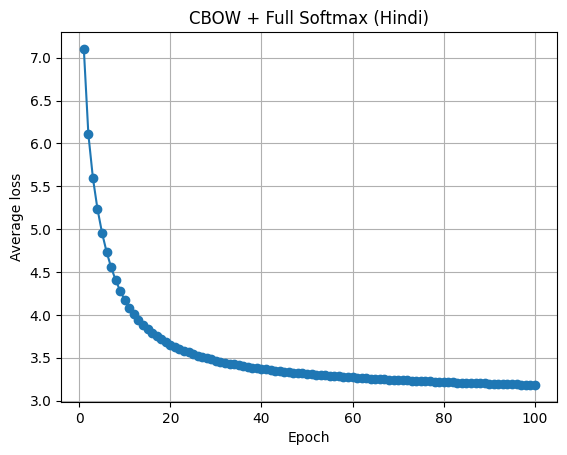

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [19]:

hi_emb_softmax = train_word2vec_softmax(hi_encoded, hi_stoi,epochs=100, label="Hindi")

with open("hi_embeddings_softmax.pkl", "wb") as f:
    pickle.dump({"embeddings": hi_emb_softmax,
                "vocab": [hi_itos[i] for i in range(len(hi_itos))],
                "stoi": hi_stoi}, f)
visualize_embeddings(hi_emb_softmax, hi_stoi, hi_itos, label="Hindi")

/tmp/ipykernel_23/3524516811.py:22: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.

[English | Full Softmax] Epoch 1/100: 100%|██████████| 480/480 [00:18<00:00, 26.23it/s, loss=6.7829]
[English | Full Softmax] Epoch 2/100: 100%|██████████| 480/480 [00:18<00:00, 26.06it/s, loss=5.9395]
[English | Full Softmax] Epoch 3/100: 100%|██████████| 480/480 [00:18<00:00, 26.09it/s, loss=5.5092]
[English | Full Softmax] Epoch 4/100: 100%|██████████| 480/480 [00:18<00:00, 25.87it/s, loss=5.1937]
[English | Full Softmax] Epoch 5/100: 100%|██████████| 480/480 [00:18<00:00, 26.06it/s, loss=4.9491]
[English | Full Softmax] Epoch 6/100: 100%|██████████| 480/480 [00:18<00:00, 25.51it/s, loss=4.7540]
[English | Full Softmax] Epoch 7/100: 100%|██████████| 480/480 [00:18<00:00, 25.85it/s, loss=4.5955]
[English | Full Softmax] Epoch 8/100: 100%|██████████| 480/480 [00:18<00:00, 25.55it/s, loss=4.4644]
[English | Full Softmax] Ep

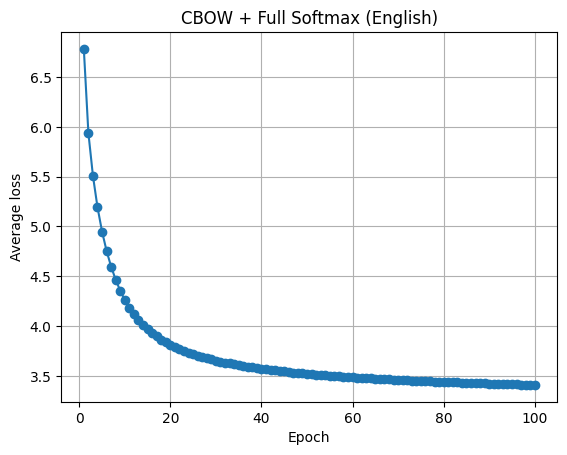

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [20]:
en_emb_softmax = train_word2vec_softmax(en_encoded, en_stoi,epochs=100, label="English")

with open("en_embeddings_softmax.pkl", "wb") as f:
    pickle.dump({"embeddings": en_emb_softmax,
                "vocab": [en_itos[i] for i in range(len(en_itos))],
                "stoi": en_stoi}, f)
visualize_embeddings(en_emb_softmax, en_stoi, en_itos, label="English")

/tmp/ipykernel_23/1141480850.py:22: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.

[Hindi] Epoch 100/100: 100%|██████████| 473/473 [00:10<00:00, 46.13it/s, loss=0.7212]


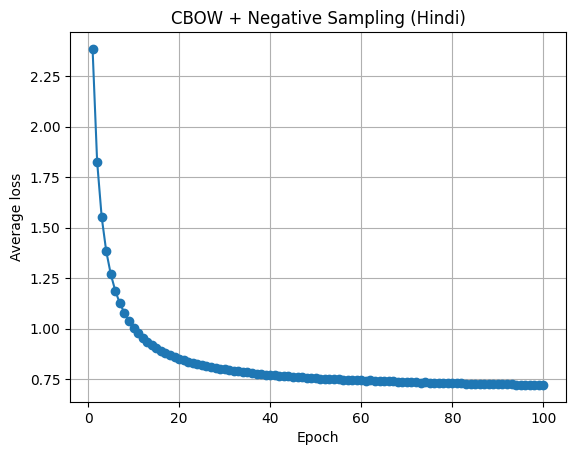

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [21]:

hi_emb_ns = train_word2vec_ns(hi_encoded, hi_stoi, hi_freq, epochs=100, label="Hindi")

with open("hi_embeddings_ns.pkl", "wb") as f:
    pickle.dump({"embeddings": hi_emb_ns,
                "vocab": [hi_itos[i] for i in range(len(hi_itos))],
                "stoi": hi_stoi}, f)
visualize_embeddings(hi_emb_ns, hi_stoi, hi_itos, label="Hindi")




/tmp/ipykernel_23/1141480850.py:22: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.

[English] Epoch 100/100: 100%|██████████| 480/480 [00:10<00:00, 46.24it/s, loss=0.8582]


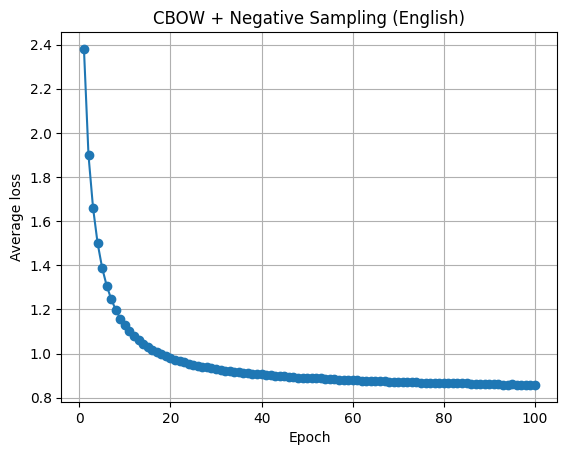

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [22]:
en_emb_ns = train_word2vec_ns(en_encoded, en_stoi, en_freq, epochs=100, label="English")

with open("en_embeddings_ns.pkl", "wb") as f:
    pickle.dump({"embeddings": en_emb_ns,
                "vocab": [en_itos[i] for i in range(len(en_itos))],
                "stoi": en_stoi}, f)
visualize_embeddings(en_emb_ns, en_stoi, en_itos, label="English")

Huffman Tree built:
 -> Leaf nodes (vocabulary words): 40955
 -> Internal nodes: 40954
 -> Total nodes: 81909


/tmp/ipykernel_23/1517322026.py:29: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.

[Hindi | Hierarchical Softmax] Epoch 1/100: 100%|██████████| 473/473 [00:10<00:00, 43.34it/s, loss=6.7088]
[Hindi | Hierarchical Softmax] Epoch 2/100: 100%|██████████| 473/473 [00:09<00:00, 47.50it/s, loss=6.1009]
[Hindi | Hierarchical Softmax] Epoch 3/100: 100%|██████████| 473/473 [00:10<00:00, 45.23it/s, loss=5.7747]
[Hindi | Hierarchical Softmax] Epoch 4/100: 100%|██████████| 473/473 [00:11<00:00, 42.31it/s, loss=5.5516]
[Hindi | Hierarchical Softmax] Epoch 5/100: 100%|██████████| 473/473 [00:10<00:00, 47.10it/s, loss=5.3871]
[Hindi | Hierarchical Softmax] Epoch 6/100: 100%|██████████| 473/473 [00:10<00:00, 46.69it/s, loss=5.2598]
[Hindi | Hierarchical Softmax] Epoch 7/100: 100%|██████████| 473/473 [00:10<00:00, 46.66it/s, loss=5.1581]
[Hindi | Hierarchical Softmax] Epoch 8/100: 100%|██████████| 473/473 [00:10<00:00, 47.

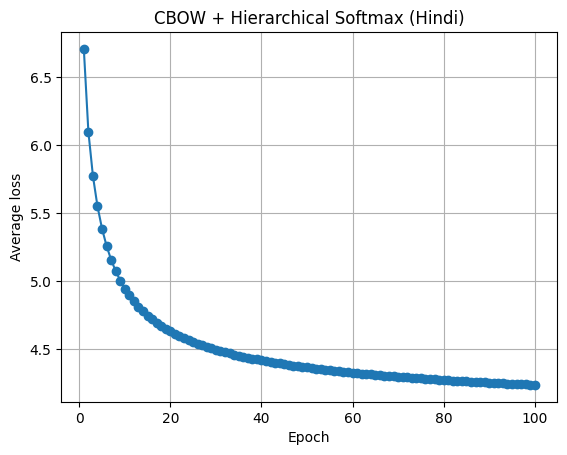

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [23]:
hi_emb_hs = train_word2vec_hs(hi_encoded, hi_stoi, hi_freq,epochs=100, label="Hindi")

with open("hi_embeddings_hs.pkl", "wb") as f:
    pickle.dump({"embeddings": hi_emb_hs,
                "vocab": [hi_itos[i] for i in range(len(hi_itos))],
                "stoi": hi_stoi}, f)
visualize_embeddings(hi_emb_hs, hi_stoi, hi_itos, label="Hindi")

Huffman Tree built:
 -> Leaf nodes (vocabulary words): 33885
 -> Internal nodes: 33884
 -> Total nodes: 67769


/tmp/ipykernel_23/1517322026.py:29: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.

[English | Hierarchical Softmax] Epoch 1/100: 100%|██████████| 480/480 [00:11<00:00, 42.83it/s, loss=6.4177]
[English | Hierarchical Softmax] Epoch 2/100: 100%|██████████| 480/480 [00:10<00:00, 45.05it/s, loss=5.8957]
[English | Hierarchical Softmax] Epoch 3/100: 100%|██████████| 480/480 [00:10<00:00, 45.46it/s, loss=5.6051]
[English | Hierarchical Softmax] Epoch 4/100: 100%|██████████| 480/480 [00:10<00:00, 47.42it/s, loss=5.4042]
[English | Hierarchical Softmax] Epoch 5/100: 100%|██████████| 480/480 [00:09<00:00, 48.22it/s, loss=5.2577]
[English | Hierarchical Softmax] Epoch 6/100: 100%|██████████| 480/480 [00:10<00:00, 44.70it/s, loss=5.1462]
[English | Hierarchical Softmax] Epoch 7/100: 100%|██████████| 480/480 [00:10<00:00, 43.85it/s, loss=5.0583]
[English | Hierarchical Softmax] Epoch 8/100: 100%|██████████| 480/480 [

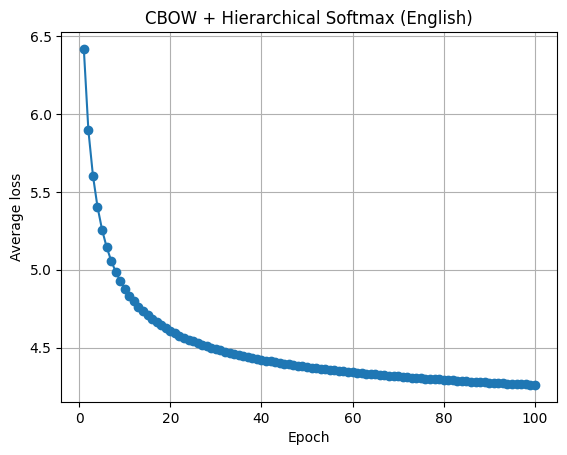

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [24]:
en_emb_hs = train_word2vec_hs(en_encoded, en_stoi, en_freq,epochs=100, label="English")

with open("en_embeddings_hs.pkl", "wb") as f:
    pickle.dump({"embeddings": en_emb_hs,
                "vocab": [en_itos[i] for i in range(len(en_itos))],
                "stoi": en_stoi}, f)
visualize_embeddings(en_emb_hs, en_stoi, en_itos, label="English")

In [25]:
# ============================================================================
# 8. TIME / COMPLEXITY COMPARISON (Section 5) — run once, on a fixed batch
# ============================================================================
def time_variant(forward_fn, n_batches=60, warmup=10):
    times = []
    for i in range(n_batches):
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        loss = forward_fn()
        loss.backward()
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        if i >= warmup:
            times.append(t1 - t0)
    return float(np.mean(times)), float(np.std(times))
 
 
def run_time_comparison(encoded_corpus, stoi, freq, embed_dim=100, window=5, batch_size=1024):
    vocab_size = len(stoi)
    set_shared_seed()
    dataset = CBOWDataset(encoded_corpus, window, vocab_size)
    contexts, targets = next(iter(DataLoader(dataset, batch_size=batch_size, shuffle=True,
                                              generator=shared_generator())))
    contexts, targets = contexts.to(DEVICE), targets.to(DEVICE)
 
    results = {}
 
    # -- Full softmax --
    fs_model = CBOWFullSoftmax(vocab_size, embed_dim).to(DEVICE)
    fs_opt = optim.Adam(fs_model.parameters(), lr=1e-3)
 
    def fs_step():
        fs_opt.zero_grad(set_to_none=True)
        return fs_model(contexts, targets)
 
    results["full_softmax"] = time_variant(fs_step)
 
    # -- Negative sampling --
    ns_model = CBOWNegativeSampling(vocab_size, embed_dim).to(DEVICE)
    ns_opt = optim.Adam(ns_model.parameters(), lr=1e-3)
    neg_table = torch.from_numpy(build_negative_sampling_table(freq, vocab_size))
 
    def ns_step():
        ns_opt.zero_grad(set_to_none=True)
        neg_idx = torch.randint(0, len(neg_table), (targets.size(0), 5))
        negatives = neg_table[neg_idx].to(DEVICE)
        return ns_model(contexts, targets, negatives)
 
    results["negative_sampling"] = time_variant(ns_step)
 
    # -- Hierarchical softmax --
    paths, codes, num_internal = build_huffman_tree(freq)
    padded_paths, padded_codes, masks = pad_paths_codes(paths, codes, vocab_size, num_internal)
    padded_paths_t = torch.from_numpy(padded_paths).to(DEVICE)
    padded_codes_t = torch.from_numpy(padded_codes).to(DEVICE)
    masks_t = torch.from_numpy(masks).to(DEVICE)
    avg_path_len = float(masks.sum(axis=1).mean())
    print(f"Average Huffman path length: {avg_path_len:.2f} (log2(V) = {np.log2(vocab_size):.2f})")
 
    hs_model = CBOWHierarchicalSoftmax(vocab_size, num_internal, embed_dim).to(DEVICE)
    hs_opt = optim.Adam(hs_model.parameters(), lr=1e-3)
 
    def hs_step():
        hs_opt.zero_grad(set_to_none=True)
        p = padded_paths_t[targets]
        c = padded_codes_t[targets]
        m = masks_t[targets]
        return hs_model(contexts, p, c, m)
 
    results["hierarchical_softmax"] = time_variant(hs_step)
 
    df = pd.DataFrame(
        [{"method": k, "mean_step_time_s": v[0], "std_s": v[1]} for k, v in results.items()]
    )
    print(df)
    fig = px.bar(df, x="method", y="mean_step_time_s", error_y="std_s",
                 title=f"Forward+backward time per batch (batch_size={batch_size}, V={vocab_size:,})")
    fig.show()
    return df, avg_path_len
 

In [26]:
# ============================================================================
# 9. ANALOGY EVALUATION
# ============================================================================
def get_predictions(df, pickle_file, output_csv, pred_col="cbow_ns_word"):
    with open(pickle_file, "rb") as f:
        data = pickle.load(f)
    E, stoi = data["embeddings"], data["stoi"]
    itos = {i: w for w, i in stoi.items()}
    norm_E = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-9)
 
    rows = []
    for _, row in df.iterrows():
        w1, w2, w3 = (str(row.iloc[i]).strip().lower() for i in range(3))
        if w1 not in stoi or w2 not in stoi or w3 not in stoi:
            pred = "OOV"
        else:
            vec = E[stoi[w1]] - E[stoi[w2]] + E[stoi[w3]]
            vec /= np.linalg.norm(vec) + 1e-9
            sims = norm_E @ vec
            for w in (w1, w2, w3):
                sims[stoi[w]] = -np.inf
            pred = itos[int(np.argmax(sims))]
        rows.append({"word1": w1, "word2": w2, "word3": w3, pred_col: pred})
 
    out_df = pd.DataFrame(rows)
    out_df.to_csv(output_csv, index=False)
    print(f"Saved {output_csv}")
    return out_df


In [27]:
time_df, avg_path_len = run_time_comparison(en_encoded, en_stoi, en_freq)

Huffman Tree built:
 -> Leaf nodes (vocabulary words): 33885
 -> Internal nodes: 33884
 -> Total nodes: 67769
Average Huffman path length: 18.02 (log2(V) = 15.05)
                 method  mean_step_time_s     std_s
0          full_softmax          0.012386  0.000764
1     negative_sampling          0.002067  0.000043
2  hierarchical_softmax          0.001537  0.000053


In [28]:
import numpy as np
import pandas as pd
import pickle
import os
import re

def generate_high_confidence_analogies_hindi(pickle_file="hi_embeddings_ns.pkl",
                                             target_num=1000,
                                             threshold=0.75,
                                             top_n_words=1000,
                                             output_csv="high_confidence_analogies_hi.csv"):
    
    set_shared_seed() # Uncomment if you have this function defined globally in your script

    print(f"Loading custom embeddings from {pickle_file}...")
    if not os.path.exists(pickle_file):
        raise FileNotFoundError(f"Could not find {pickle_file}")

    with open(pickle_file, "rb") as f:
        data = pickle.load(f)
        custom_E = data["embeddings"]
        stoi = data["stoi"]
        itos = {i: w for w, i in stoi.items()}

    # Normalize the embedding matrix for fast cosine similarity
    norms = np.linalg.norm(custom_E, axis=1, keepdims=True)
    norm_custom_E = custom_E / (norms + 1e-9)

    # --- W1, W2, W3 STRICT HINDI FILTERING ---
    # Must be Devanagari characters ONLY AND have a length of at least 3 characters
    candidate_pool = []
    
    # Iterate through keys sorted by index (assuming lower index = higher frequency)
    for idx in sorted(itos.keys()):
        w = itos[idx]
        
        # re.match ensures the word consists entirely of Hindi (Devanagari) characters
        if isinstance(w, str) and len(w) >= 3 and re.match(r'^[\u0900-\u097F]+$', w):
            candidate_pool.append(w)
            
        if len(candidate_pool) >= top_n_words:
            break

    if len(candidate_pool) < 3:
        print("Error: Not enough words in the vocabulary matching the strictly Hindi criteria.")
        return pd.DataFrame()

    print(f"Hunting for {target_num} analogies with > {threshold} confidence...")

    results = []
    attempts = 0
    max_attempts = 20000 # Safety net to prevent infinite loops

    while len(results) < target_num and attempts < max_attempts:
        attempts += 1

        # Pick 3 unique random words from our STRICTLY HINDI candidate pool
        w1, w2, w3 = np.random.choice(candidate_pool, size=3, replace=False)

        # 1. Vector Math: w1 - w2 + w3
        v_vec = custom_E[stoi[w1]] - custom_E[stoi[w2]] + custom_E[stoi[w3]]
        v_vec = v_vec / (np.linalg.norm(v_vec) + 1e-9)

        # 2. Compute Cosine Similarity against all words
        sims = np.dot(norm_custom_E, v_vec)

        # 3. Mask out the input words so they aren't chosen as w4
        # (w4 is allowed to be ANYTHING else, so no invalid_mask is applied here)
        for w in [w1, w2, w3]:
            sims[stoi[w]] = -np.inf

        # 4. Find the closest valid word
        best_idx = np.argmax(sims)
        
        # Guard in case best_idx maps to an extra embedding without a string mapping
        if best_idx not in itos:
            continue
            
        w4 = itos[best_idx]
        score = float(sims[best_idx])

        # --- THE FILTER ---
        if score > threshold:
            results.append({
                "word1": w1,
                "word2": w2,
                "word3": w3,
                "word4": w4,
                "equation": f"{w1} - {w2} + {w3} = {w4}",
                "confidence_score": round(score, 4)
            })

    # --- SAVE TO CSV ---
    out_df = pd.DataFrame(results)

    if len(out_df) == 0:
        print(f"\nWARNING: Could not find ANY analogies > {threshold} after {max_attempts} attempts.")
        print("Your model's vectors might be too spread out. Try lowering the threshold.")
        return out_df

    # Sort from highest confidence to lowest
    out_df = out_df.sort_values(by="confidence_score", ascending=False)
    out_df.to_csv(output_csv, index=False)

    print(f"\n-> Success! Found {len(out_df)} analogies out of {attempts} random attempts.")
    print(f"-> Saved to '{output_csv}'!")

    return out_df

In [32]:
import numpy as np
import pandas as pd
import pickle
import os

def generate_high_confidence_analogies(pickle_file="embeddings.pkl",
                                       target_num=1000,
                                       threshold=0.75,
                                       top_n_words=1000,
                                       output_csv="high_confidence_analogies.csv"):
    set_shared_seed()

    print(f"Loading custom embeddings from {pickle_file}...")
    if not os.path.exists(pickle_file):
        raise FileNotFoundError(f"Could not find {pickle_file}")

    with open(pickle_file, "rb") as f:
        data = pickle.load(f)
        custom_E = data["embeddings"]
        stoi = data["stoi"]
        itos = {i: w for w, i in stoi.items()}

    # Normalize the embedding matrix for fast cosine similarity
    norms = np.linalg.norm(custom_E, axis=1, keepdims=True)
    norm_custom_E = custom_E / (norms + 1e-9)

    # --- W1, W2, W3 FILTERING (English & Hindi) ---
    # Must be alphabetical AND have a length of at least 3 characters
    candidate_pool = []
    
    # Iterate through keys sorted by index (assuming lower index = higher frequency)
    for idx in sorted(itos.keys()):
        w = itos[idx]
        if isinstance(w, str) and w.isalpha() and len(w) >= 3:
            candidate_pool.append(w)
        if len(candidate_pool) >= top_n_words:
            break

    if len(candidate_pool) < 3:
        print("Error: Not enough words in the vocabulary matching the criteria (alphabetic, len >= 3).")
        return pd.DataFrame()

    print(f"Hunting for {target_num} analogies with > {threshold} confidence...")

    results = []
    attempts = 0
    max_attempts = 20000 # Safety net to prevent infinite loops

    while len(results) < target_num and attempts < max_attempts:
        attempts += 1

        # Pick 3 unique random words from our filtered candidate pool
        w1, w2, w3 = np.random.choice(candidate_pool, size=3, replace=False)

        # 1. Vector Math: w1 - w2 + w3
        v_vec = custom_E[stoi[w1]] - custom_E[stoi[w2]] + custom_E[stoi[w3]]
        v_vec = v_vec / (np.linalg.norm(v_vec) + 1e-9)

        # 2. Compute Cosine Similarity against all words
        sims = np.dot(norm_custom_E, v_vec)

        # 3. Mask out the input words so they aren't chosen as w4
        # (w4 is allowed to be ANYTHING else, so no invalid_mask is applied here)
        for w in [w1, w2, w3]:
            sims[stoi[w]] = -np.inf

        # 4. Find the closest valid word
        best_idx = np.argmax(sims)
        
        # Guard in case best_idx maps to an extra embedding without a string mapping
        if best_idx not in itos:
            continue
            
        w4 = itos[best_idx]
        score = float(sims[best_idx])

        # --- THE FILTER ---
        if score > threshold:
            results.append({
                "word1": w1,
                "word2": w2,
                "word3": w3,
                "word4": w4,
                "equation": f"{w1} - {w2} + {w3} = {w4}",
                "confidence_score": round(score, 4)
            })

    # --- SAVE TO CSV ---
    out_df = pd.DataFrame(results)

    if len(out_df) == 0:
        print(f"\nWARNING: Could not find ANY analogies > {threshold} after {max_attempts} attempts.")
        print("Your model's vectors might be too spread out. Try lowering the threshold to 0.60.")
        return out_df

    # Sort from highest confidence to lowest
    out_df = out_df.sort_values(by="confidence_score", ascending=False)
    out_df.to_csv(output_csv, index=False)

    print(f"\n-> Success! Found {len(out_df)} analogies out of {attempts} random attempts.")
    print(f"-> Saved to '{output_csv}'!")

    return out_df